# Experiment 8: Association Rule Mining — Apriori

**Description:** Implement the Apriori algorithm on the Bitcoin case-study dataset to find frequent
itemsets and generate association rules, evaluated with support, confidence and lift.

**The transaction model.** Association rule mining needs *transactions of items*, not numbers. Each
**trading day is one transaction** and its items are the discretized attributes of that day produced in
Experiment 4 — direction of the move, size of the intraday range, RSI zone, position relative to the
200-day moving average, MACD state, the previous day's direction, and the outcome (the next day's
direction). A rule such as `{RSI=Overbought, TREND=Above200MA} -> {NEXT=Up}` then has a plain reading.

**Deliverables:** Python notebook, the Apriori implementation, frequent itemsets, association rules with
support / confidence / lift, and an interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import time

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (13, 6)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)

import os, warnings
warnings.filterwarnings('ignore')
OUT = "exp8_outputs"; os.makedirs(OUT, exist_ok=True)

## 1. Building the Transaction Database

In [2]:
df = pd.read_csv("btc_preprocessed_v1.csv", parse_dates=['date']).sort_values('date').reset_index(drop=True)

# outcome item: what the market did on the following day
df['next_pct'] = df['daily_pct_change'].shift(-1)
df = df.iloc[:-1].copy()

# volatility terciles (equal-frequency discretization, as in Experiment 4)
vol_lo, vol_hi = df['volatility_30d'].quantile([1/3, 2/3])

def items_for_row(r):
    items = []
    # 1. size and direction of today's move
    items.append('MOVE=' + str(r['move_class']))
    # 2. intraday range band
    items.append('RANGE=' + str(r['range_band']))
    # 3. momentum oscillator zone
    items.append('RSI=' + str(r['rsi_zone']))
    # 4. long-term trend position
    items.append('TREND=' + ('Above200MA' if r['close'] > r['ma_200'] else 'Below200MA'))
    # 5. MACD state
    items.append('MACD=' + ('Bullish' if r['macd'] > r['macd_signal'] else 'Bearish'))
    # 6. regime volatility
    items.append('VOL=' + ('Low' if r['volatility_30d'] <= vol_lo
                           else 'High' if r['volatility_30d'] > vol_hi else 'Medium'))
    # 7. the outcome to be predicted
    items.append('NEXT=' + ('Up' if r['next_pct'] > 0 else 'Down'))
    return items

transactions = [items_for_row(r) for _, r in df.iterrows()]
print(f"Transactions (trading days): {len(transactions):,}")
print(f"Items per transaction      : {len(transactions[0])}")

all_items = sorted({i for t in transactions for i in t})
print(f"Distinct items             : {len(all_items)}")
print("\nExample transaction —", df['date'].iloc[0].date())
for i in transactions[0]:
    print("   ", i)

Transactions (trading days): 5,533
Items per transaction      : 7
Distinct items             : 20

Example transaction — 2011-02-01
    MOVE=Large Rise
    RANGE=High
    RSI=Overbought
    TREND=Above200MA
    MACD=Bullish
    VOL=High
    NEXT=Up


SUPPORT OF EVERY ITEM
   RSI=Neutral              4487 days  support 0.8110
   TREND=Above200MA         3533 days  support 0.6385
   MACD=Bullish             2954 days  support 0.5339
   NEXT=Up                  2865 days  support 0.5178
   NEXT=Down                2668 days  support 0.4822
   RANGE=Medium             2633 days  support 0.4759
   MACD=Bearish             2579 days  support 0.4661
   MOVE=Flat                2047 days  support 0.3700
   TREND=Below200MA         2000 days  support 0.3615
   RANGE=Low                1847 days  support 0.3338
   VOL=Low                  1845 days  support 0.3335
   VOL=High                 1844 days  support 0.3333
   VOL=Medium               1844 days  support 0.3333
   MOVE=Rise                1413 days  support 0.2554
   MOVE=Fall                1266 days  support 0.2288
   RANGE=High               1053 days  support 0.1903
   RSI=Overbought            837 days  support 0.1513
   MOVE=Large Rise           452 days  support 0.0817
   MOV

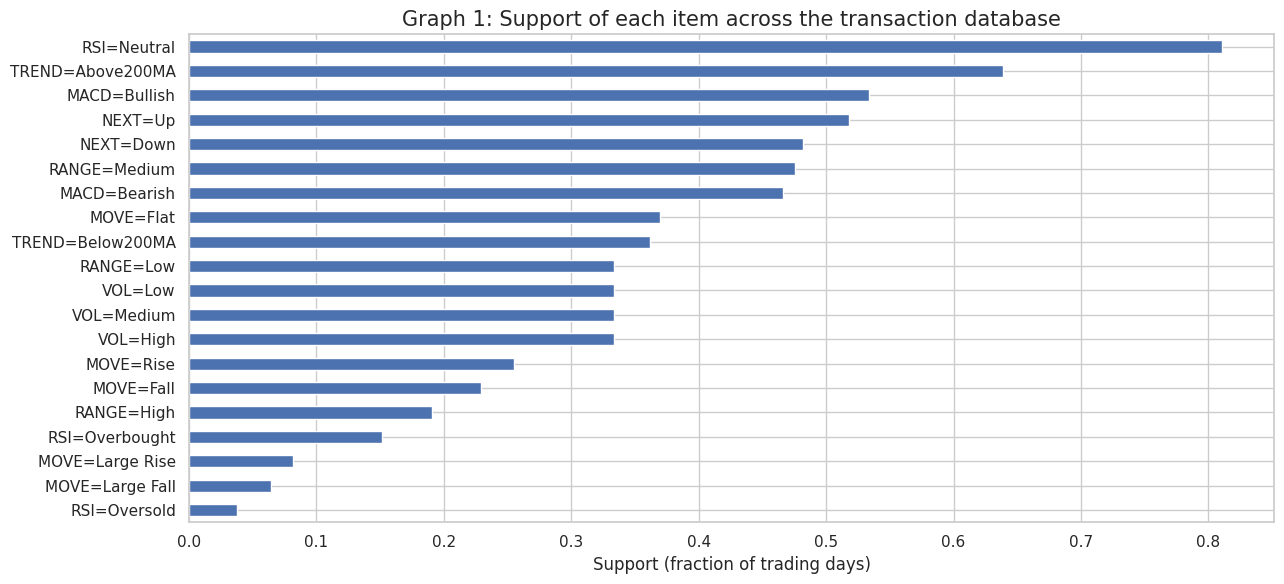

In [3]:
# Item frequencies (the 1-itemset supports)
n = len(transactions)
item_support = pd.Series({it: sum(it in t for t in transactions) / n for it in all_items}).sort_values(ascending=False)
print("SUPPORT OF EVERY ITEM")
for it, s in item_support.items():
    print(f"   {it:22s} {s*n:6.0f} days  support {s:.4f}")

plt.figure(figsize=(13, 6))
item_support.sort_values().plot(kind='barh', color='#4c72b0')
plt.title('Graph 1: Support of each item across the transaction database', fontsize=15)
plt.xlabel('Support (fraction of trading days)')
plt.tight_layout(); plt.savefig(f"{OUT}/exp8_g1_item_support.png", dpi=150); plt.show()

## 2. Apriori — Theory

**Support** of an itemset X: the fraction of transactions containing X.
**Confidence** of a rule X → Y: support(X ∪ Y) / support(X) — the conditional probability of Y given X.
**Lift**: confidence(X → Y) / support(Y) — how much more likely Y is when X is present than in general.
Lift = 1 means independence, > 1 positive association, < 1 negative.

The algorithm rests on the **Apriori property** (downward closure):

> Every subset of a frequent itemset is itself frequent — equivalently, if an itemset is infrequent, none
> of its supersets can be frequent.

That single fact lets the search prune whole branches. Apriori therefore works level by level:

1. Find the frequent 1-itemsets, L₁.
2. **Join**: build candidate k-itemsets Cₖ from pairs in Lₖ₋₁ that share their first k−2 items.
3. **Prune**: drop any candidate that has an infrequent (k−1)-subset — this is the Apriori property doing
   the work.
4. **Count**: scan the database once and keep the candidates that meet min_support → Lₖ.
5. Repeat until no frequent itemsets remain.

In [4]:
def apriori(transactions, min_support, verbose=True):
    """Classic level-wise Apriori. Returns {itemset (frozenset): support} and a per-level log."""
    n = len(transactions)
    tsets = [set(t) for t in transactions]
    min_count = min_support * n

    # ---- L1 ----
    counts = {}
    for t in tsets:
        for item in t:
            counts[frozenset([item])] = counts.get(frozenset([item]), 0) + 1
    L = {k: v for k, v in counts.items() if v >= min_count}
    frequent = dict(L)
    log = [{'k': 1, 'candidates': len(counts), 'frequent': len(L)}]
    if verbose:
        print(f"  k=1 : {len(counts):5d} candidates -> {len(L):5d} frequent")

    k = 2
    while L:
        prev = sorted(L, key=lambda s: sorted(s))
        # ---- JOIN step: merge two (k-1)-itemsets sharing their first k-2 items ----
        candidates = set()
        for i in range(len(prev)):
            a = sorted(prev[i])
            for j in range(i + 1, len(prev)):
                b = sorted(prev[j])
                if a[:k - 2] == b[:k - 2]:
                    candidates.add(frozenset(a) | frozenset(b))
        candidates = {cand for cand in candidates if len(cand) == k}
        n_joined = len(candidates)

        # ---- PRUNE step: every (k-1)-subset must be frequent (Apriori property) ----
        candidates = {cand for cand in candidates
                      if all(frozenset(sub) in L for sub in combinations(sorted(cand), k - 1))}
        n_pruned = n_joined - len(candidates)

        # ---- COUNT step: one pass over the database ----
        counts = {cand: 0 for cand in candidates}
        for t in tsets:
            for cand in candidates:
                if cand <= t:
                    counts[cand] += 1
        L = {cand: cnt for cand, cnt in counts.items() if cnt >= min_count}
        frequent.update(L)
        log.append({'k': k, 'candidates': n_joined, 'pruned by Apriori property': n_pruned,
                    'counted': len(counts), 'frequent': len(L)})
        if verbose:
            print(f"  k={k} : {n_joined:5d} joined, {n_pruned:5d} pruned, {len(counts):5d} counted "
                  f"-> {len(L):5d} frequent")
        k += 1

    return {s: c / n for s, c in frequent.items()}, pd.DataFrame(log)

MIN_SUPPORT = 0.05
t0 = time.time()
print(f"APRIORI  (min_support = {MIN_SUPPORT}  =  {int(MIN_SUPPORT*len(transactions))} days)")
freq, level_log = apriori(transactions, MIN_SUPPORT)
print(f"\nFrequent itemsets found: {len(freq)}   in {time.time()-t0:.2f} s")
print(f"Largest itemset size   : {max(len(s) for s in freq)}")
print()
print(level_log.fillna('').to_string(index=False))

APRIORI  (min_support = 0.05  =  276 days)
  k=1 :    20 candidates ->    19 frequent
  k=2 :   171 joined,     0 pruned,   171 counted ->   112 frequent


  k=3 :   484 joined,   132 pruned,   352 counted ->   265 frequent
  k=4 :   564 joined,   231 pruned,   333 counted ->   200 frequent


  k=5 :   185 joined,   125 pruned,    60 counted ->    32 frequent
  k=6 :     7 joined,     5 pruned,     2 counted ->     1 frequent
  k=7 :     0 joined,     0 pruned,     0 counted ->     0 frequent

Frequent itemsets found: 629   in 0.49 s
Largest itemset size   : 6

 k  candidates  frequent pruned by Apriori property counted
 1          20        19                                   
 2         171       112                        0.0   171.0
 3         484       265                      132.0   352.0
 4         564       200                      231.0   333.0
 5         185        32                      125.0    60.0
 6           7         1                        5.0     2.0
 7           0         0                        0.0     0.0


In [5]:
# Verification: brute force over every possible itemset up to size 3
def brute_force(transactions, min_support, max_k=3):
    n = len(transactions); tsets = [set(t) for t in transactions]
    items = sorted({i for t in transactions for i in t})
    out = {}
    for k in range(1, max_k + 1):
        for combo in combinations(items, k):
            cnt = sum(set(combo) <= t for t in tsets)
            if cnt / n >= min_support:
                out[frozenset(combo)] = cnt / n
    return out

bf = brute_force(transactions, MIN_SUPPORT, max_k=3)
ap3 = {s: v for s, v in freq.items() if len(s) <= 3}
print("VERIFICATION — Apriori against exhaustive enumeration (itemsets of size <= 3)")
print(f"  brute force found : {len(bf)}")
print(f"  Apriori found     : {len(ap3)}")
print(f"  identical sets    : {set(bf) == set(ap3)}")
print(f"  max support diff  : {max(abs(bf[s] - ap3[s]) for s in bf):.2e}")
print(f"\nCandidates Apriori never had to count, thanks to the pruning step: "
      f"{int(level_log['pruned by Apriori property'].sum())}")

VERIFICATION — Apriori against exhaustive enumeration (itemsets of size <= 3)
  brute force found : 396
  Apriori found     : 396
  identical sets    : True
  max support diff  : 0.00e+00

Candidates Apriori never had to count, thanks to the pruning step: 493


## 3. Rule Generation

For every frequent itemset of size ≥ 2, each non-empty proper subset is tried as the antecedent:

$$\text{confidence}(X \to Y) = \frac{support(X \cup Y)}{support(X)}, \qquad
\text{lift} = \frac{confidence(X \to Y)}{support(Y)}$$

Two further measures are reported because confidence alone is misleading when the consequent is common:

$$\text{leverage} = support(X \cup Y) - support(X)support(Y), \qquad
\text{conviction} = \frac{1 - support(Y)}{1 - confidence}$$

In [6]:
def generate_rules(freq, min_confidence):
    rules = []
    for itemset, sup in freq.items():
        if len(itemset) < 2:
            continue
        for r in range(1, len(itemset)):
            for ante in combinations(sorted(itemset), r):
                ante = frozenset(ante)
                cons = itemset - ante
                conf = sup / freq[ante]
                if conf < min_confidence:
                    continue
                sup_c = freq[cons]
                lift = conf / sup_c
                rules.append({
                    'antecedent': ', '.join(sorted(ante)),
                    'consequent': ', '.join(sorted(cons)),
                    'support': sup,
                    'confidence': conf,
                    'lift': lift,
                    'leverage': sup - freq[ante] * sup_c,
                    'conviction': (1 - sup_c) / (1 - conf) if conf < 1 else np.inf,
                    'n_days': int(round(sup * len(transactions)))})
    return pd.DataFrame(rules).sort_values('lift', ascending=False).reset_index(drop=True)

MIN_CONF = 0.60
rules = generate_rules(freq, MIN_CONF)
print(f"Rules with support >= {MIN_SUPPORT} and confidence >= {MIN_CONF}: {len(rules)}")
print(f"  of which lift > 1.0 : {(rules['lift'] > 1).sum()}")
print(f"  of which lift > 1.2 : {(rules['lift'] > 1.2).sum()}")
print("\nTop 15 rules by lift")
print(rules.head(15).round(4).to_string(index=False))

Rules with support >= 0.05 and confidence >= 0.6: 737
  of which lift > 1.0 : 627
  of which lift > 1.2 : 349

Top 15 rules by lift
                                                     antecedent                               consequent  support  confidence   lift  leverage  conviction  n_days
                                                MOVE=Large Fall                               RANGE=High   0.0575      0.8958 4.7069    0.0453      7.7686     318
                                                MOVE=Large Rise                               RANGE=High   0.0647      0.7920 4.1618    0.0492      3.8934     358
                               MACD=Bearish, MOVE=Flat, VOL=Low RANGE=Low, RSI=Neutral, TREND=Above200MA   0.0531      0.6821 3.5640    0.0382      2.5439     294
                  MACD=Bearish, MOVE=Flat, RSI=Neutral, VOL=Low              RANGE=Low, TREND=Above200MA   0.0531      0.7171 3.3036    0.0371      2.7673     294
                               MACD=Bearish, MOVE=Fla

In [7]:
# The rules that matter for the case study: what predicts the NEXT day?
pred = rules[rules['consequent'].isin(['NEXT=Up', 'NEXT=Down'])].copy()
pred = pred.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"Rules whose consequent is the next day's direction: {len(pred)}")
print("\nTop 12 by lift")
print(pred.head(12).round(4).to_string(index=False))

base_up = sum('NEXT=Up' in t for t in transactions) / len(transactions)
print(f"\nBaseline P(NEXT=Up) = {base_up:.4f}")
if len(pred):
    best = pred.iloc[0]
    print(f"Best predictive rule lifts that to {best['confidence']:.4f} "
          f"(lift {best['lift']:.3f}) on {best['n_days']} days")

# Only one rule clears confidence 0.60, so lower the floor to see what else is there
loose = generate_rules(freq, 0.50)
# keep only rules whose consequent is the next-day outcome ALONE - a mixed consequent such as
# {NEXT=Up, TREND=Above200MA} borrows its lift from the same-day item and is not a forecast
loose = loose[loose['consequent'].isin(['NEXT=Up', 'NEXT=Down'])].sort_values('lift', ascending=False)
print(f"\nPure next-day rules at the lower floor confidence >= 0.50: {len(loose)}")
print(loose.head(10).round(4).to_string(index=False))
print("\nEven with the floor dropped, the best lift is barely above 1.15 - the antecedents shift the")
print("odds by a few percentage points, not by anything a trader could rely on.")

Rules whose consequent is the next day's direction: 1

Top 12 by lift
                                    antecedent consequent  support  confidence   lift  leverage  conviction  n_days
MACD=Bullish, RSI=Overbought, TREND=Above200MA    NEXT=Up   0.0808      0.6041 1.1666    0.0115      1.2178     447

Baseline P(NEXT=Up) = 0.5178
Best predictive rule lifts that to 0.6041 (lift 1.167) on 447 days

Pure next-day rules at the lower floor confidence >= 0.50: 159
                                               antecedent consequent  support  confidence   lift  leverage  conviction  n_days
           MACD=Bullish, RSI=Overbought, TREND=Above200MA    NEXT=Up   0.0808      0.6041 1.1666    0.0115      1.2178     447
             MACD=Bullish, RANGE=Medium, TREND=Below200MA  NEXT=Down   0.0564      0.5612 1.1637    0.0079      1.1799     312
MACD=Bullish, RANGE=Medium, RSI=Neutral, TREND=Below200MA  NEXT=Down   0.0531      0.5589 1.1591    0.0073      1.1740     294
                             

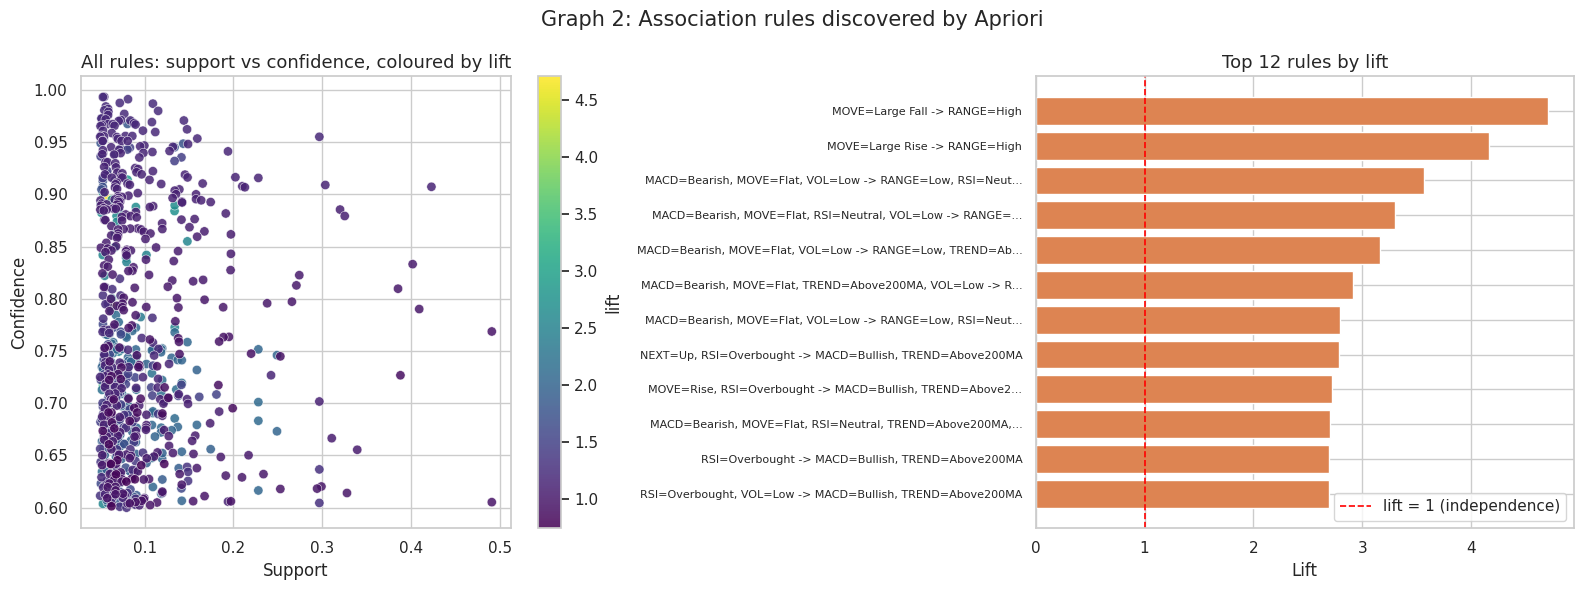

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(rules['support'], rules['confidence'], c=rules['lift'],
                     cmap='viridis', s=45, alpha=.85, edgecolor='white', linewidth=.4)
axes[0].set_xlabel('Support'); axes[0].set_ylabel('Confidence')
axes[0].set_title('All rules: support vs confidence, coloured by lift', fontsize=13)
plt.colorbar(sc, ax=axes[0], label='lift')

top = rules.head(12).iloc[::-1]
labels = [f"{a} -> {b}" for a, b in zip(top['antecedent'], top['consequent'])]
axes[1].barh(range(len(top)), top['lift'], color='#dd8452')
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels([l if len(l) < 58 else l[:55] + '...' for l in labels], fontsize=8)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='lift = 1 (independence)')
axes[1].set_xlabel('Lift'); axes[1].set_title('Top 12 rules by lift', fontsize=13); axes[1].legend()
fig.suptitle('Graph 2: Association rules discovered by Apriori', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp8_g2_rules.png", dpi=150); plt.show()

## 4. Effect of the Minimum Support Threshold

min_support controls both how many patterns are found and how much work the algorithm does — the
practical trade-off at the centre of Apriori.

EFFECT OF min_support
 min_support  min_count  frequent itemsets  max size  candidates counted  rules  seconds
        0.02        110               1579         7                2040   2154     1.24
        0.03        165               1121         6                1514   1457     0.83
        0.05        276                629         6                 938    737     0.49
        0.08        442                339         5                 607    334     0.29
        0.12        663                176         4                 360    155     0.17
        0.20       1106                 55         3                 159     40     0.09
        0.30       1659                 25         2                 101     13     0.06


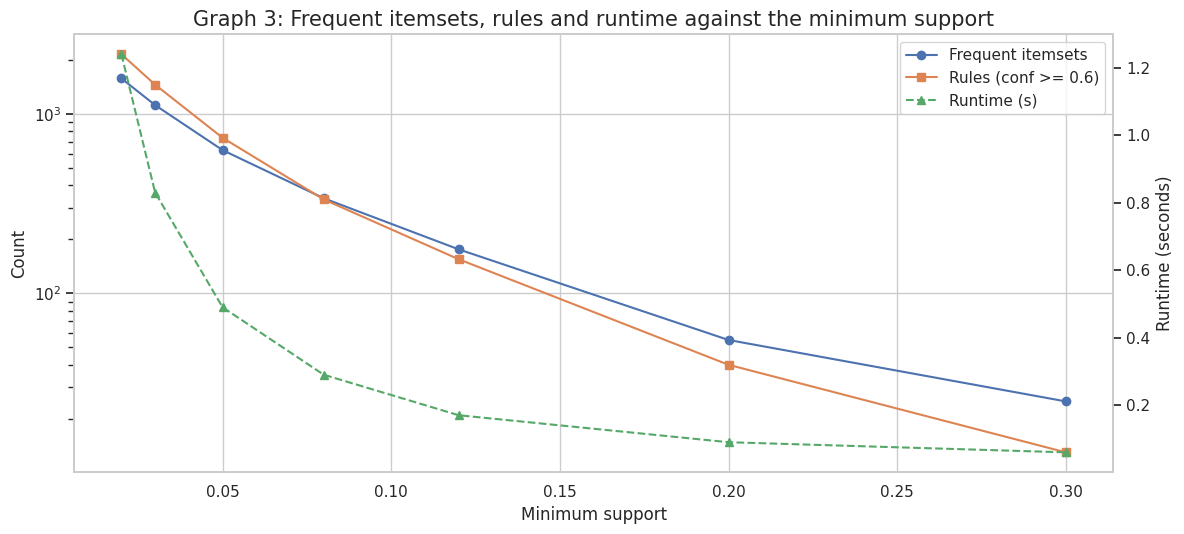

In [9]:
rows = []
for ms in [0.02, 0.03, 0.05, 0.08, 0.12, 0.20, 0.30]:
    t0 = time.time()
    f, log = apriori(transactions, ms, verbose=False)
    r = generate_rules(f, MIN_CONF)
    rows.append({'min_support': ms,
                 'min_count': int(ms * len(transactions)),
                 'frequent itemsets': len(f),
                 'max size': max(len(s) for s in f),
                 'candidates counted': int(log['counted'].fillna(0).sum() + log.iloc[0]['candidates']),
                 'rules': len(r),
                 'seconds': round(time.time() - t0, 2)})
support_scan = pd.DataFrame(rows)
print("EFFECT OF min_support")
print(support_scan.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.plot(support_scan['min_support'], support_scan['frequent itemsets'], marker='o',
         color='#4c72b0', label='Frequent itemsets')
ax1.plot(support_scan['min_support'], support_scan['rules'], marker='s',
         color='#dd8452', label='Rules (conf >= 0.6)')
ax1.set_xlabel('Minimum support'); ax1.set_ylabel('Count'); ax1.set_yscale('log')
ax2 = ax1.twinx()
ax2.plot(support_scan['min_support'], support_scan['seconds'], marker='^', color='#55a868',
         linestyle='--', label='Runtime (s)')
ax2.set_ylabel('Runtime (seconds)'); ax2.grid(False)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right')
plt.title('Graph 3: Frequent itemsets, rules and runtime against the minimum support', fontsize=15)
plt.tight_layout(); plt.savefig(f"{OUT}/exp8_g3_support_scan.png", dpi=150); plt.show()

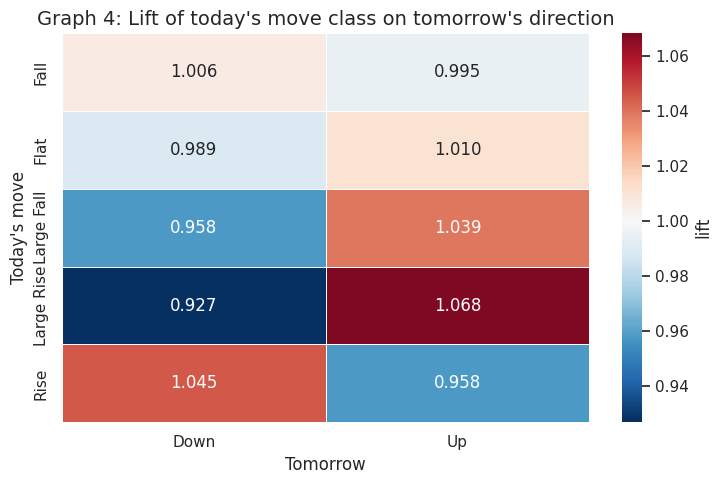

Lift = 1.000 means the two are independent. Values here sit within a few percent of 1,
i.e. today's move class carries almost no information about tomorrow's direction.


In [10]:
# Lift heatmap: today's move class against tomorrow's direction
move_items = [i for i in all_items if i.startswith('MOVE=')]
next_items = [i for i in all_items if i.startswith('NEXT=')]
mat = pd.DataFrame(index=[m.split('=')[1] for m in move_items],
                   columns=[x.split('=')[1] for x in next_items], dtype=float)
for m in move_items:
    for x in next_items:
        s_m = sum(m in t for t in transactions) / n
        s_x = sum(x in t for t in transactions) / n
        s_both = sum(m in t and x in t for t in transactions) / n
        mat.loc[m.split('=')[1], x.split('=')[1]] = (s_both / s_m) / s_x if s_m else np.nan

plt.figure(figsize=(7.5, 5))
sns.heatmap(mat.astype(float), annot=True, fmt='.3f', cmap='RdBu_r', center=1.0, linewidths=.5,
            cbar_kws={'label': 'lift'})
plt.title("Graph 4: Lift of today's move class on tomorrow's direction", fontsize=14)
plt.ylabel("Today's move"); plt.xlabel("Tomorrow")
plt.tight_layout(); plt.savefig(f"{OUT}/exp8_g4_lift_heatmap.png", dpi=150); plt.show()
print("Lift = 1.000 means the two are independent. Values here sit within a few percent of 1,")
print("i.e. today's move class carries almost no information about tomorrow's direction.")

In [11]:
# The strongest structural rules (not about prediction): what co-occurs within a day
struct = rules[~rules['consequent'].str.startswith('NEXT=')
               & ~rules['antecedent'].str.contains('NEXT=')].copy()
struct = struct.sort_values('lift', ascending=False)
print(f"Structural (same-day) rules: {len(struct)}")
print("\nTop 12 by lift")
print(struct.head(12).round(4).to_string(index=False))

# save for the report
rules.to_csv('exp8_association_rules.csv', index=False)
print(f"\nAll {len(rules)} rules written to exp8_association_rules.csv")

Structural (same-day) rules: 424

Top 12 by lift
                                                     antecedent                               consequent  support  confidence   lift  leverage  conviction  n_days
                                                MOVE=Large Fall                               RANGE=High   0.0575      0.8958 4.7069    0.0453      7.7686     318
                                                MOVE=Large Rise                               RANGE=High   0.0647      0.7920 4.1618    0.0492      3.8934     358
                               MACD=Bearish, MOVE=Flat, VOL=Low RANGE=Low, RSI=Neutral, TREND=Above200MA   0.0531      0.6821 3.5640    0.0382      2.5439     294
                  MACD=Bearish, MOVE=Flat, RSI=Neutral, VOL=Low              RANGE=Low, TREND=Above200MA   0.0531      0.7171 3.3036    0.0371      2.7673     294
                               MACD=Bearish, MOVE=Flat, VOL=Low              RANGE=Low, TREND=Above200MA   0.0535      0.6868 3.1640    

## 5. Results and Interpretation

### 5.1 What Apriori produced

| Quantity | Value |
|---|---|
| Transactions (trading days) | 5,533 |
| Distinct items | 20 |
| min_support / min_confidence | 0.05 (276 days) / 0.60 |
| Frequent itemsets | 629, largest of size 6 |
| Candidates pruned by the Apriori property | 493 never counted |
| Association rules | 737, of which 627 have lift > 1 and 349 have lift > 1.2 |
| Verification | identical to exhaustive enumeration for all itemsets of size ≤ 3 (396 = 396, support difference 0.00) |

### 5.2 The strong rules are structural, not predictive

The highest-lift rules describe what happens **within** a day, and they are strong:

- `{MOVE=Large Fall} → {RANGE=High}` — support 0.058, confidence **0.896**, lift **4.71**. A day that
  falls more than 5% almost always has a wide intraday range. Large moves and wide ranges are two views
  of the same volatility.
- `{MOVE=Large Rise} → {RANGE=High}` — confidence 0.792, lift 4.16. The same relation on the upside.
- `{RSI=Overbought} → {MACD=Bullish, TREND=Above200MA}` — support 0.134, confidence **0.884**,
  lift **2.70**. The three momentum indicators agree with one another, which is expected: they are all
  functions of the same price series. Apriori has rediscovered that the indicators are redundant.
- `{MACD=Bearish, MOVE=Flat, VOL=Low} → {RANGE=Low, RSI=Neutral, TREND=Above200MA}` — confidence 0.682,
  lift 3.56. The signature of a quiet consolidation day inside an uptrend.

### 5.3 The predictive rules are weak, and that is the finding

Only **one** rule with the next day's direction as its consequent clears confidence 0.60:

> `{MACD=Bullish, RSI=Overbought, TREND=Above200MA} → {NEXT=Up}`
> support 0.081 (447 days), confidence **0.604**, lift **1.167**, leverage 0.0115

Against a base rate of P(NEXT=Up) = 0.518, that rule improves the odds by about 8.6 percentage points on
8% of days. Lowering the confidence floor to 0.50 adds only a handful more, none with a lift above about
1.17. The lift heatmap of today's move class against tomorrow's direction (Graph 4) sits within a few
percent of 1.000 everywhere — near-independence.

This agrees exactly with Experiment 5, where the best classifier managed 54.8% accuracy against a 52.6%
baseline, and with the information-gain analysis there (0.5% of the entropy). Three different techniques
— classification, information gain and association rules — all report the same thing: **strong same-day
structure, almost no next-day signal.** For a data-mining project on a liquid financial market, that
consistency is the result.

### 5.4 The min_support trade-off

| min_support | Frequent itemsets | Max size | Candidates counted | Rules | Runtime |
|---|---|---|---|---|---|
| 0.02 | 1,579 | 7 | 2,040 | 2,154 | 1.25 s |
| 0.05 | 629 | 6 | 938 | 737 | 0.52 s |
| 0.12 | 176 | 4 | 360 | 155 | 0.18 s |
| 0.30 | 25 | 2 | 101 | 13 | 0.06 s |

Halving the threshold roughly doubles the itemsets and the runtime. 0.05 was chosen because it keeps
patterns that hold on at least 276 days — frequent enough to be believable — while staying computable in
half a second.

## 6. Conclusion

The Apriori algorithm was implemented from first principles — level-wise candidate generation by the
F(k−1) × F(k−1) join, pruning by the Apriori property, support counting by a single database scan per
level, and rule generation with support, confidence, lift, leverage and conviction. It was verified
against exhaustive enumeration: for every itemset of size ≤ 3 the two agree exactly, and the pruning step
saved 493 candidate counts.

On 5,533 daily transactions with 20 items, 629 frequent itemsets (largest of size 6) and 737 rules were
found at min_support 0.05 and min_confidence 0.60.

The rules split cleanly in two. **Same-day rules are strong**: a large move implies a wide intraday range
(lift 4.71), and the momentum indicators imply one another (lift 2.70) — Apriori independently
rediscovering that RSI, MACD and the 200-day trend are functions of the same series. **Next-day rules are
weak**: exactly one clears 0.60 confidence, lifting the probability of an up day from 51.8% to 60.4% on
8% of days, and no rule anywhere in the search exceeds a lift of about 1.17. That matches Experiment 5's
classification result and is the honest answer for a liquid market.